# **Electric Vehicle Adoption Analysis and Range Prediction**

---


**Innovexa Catalyst 2026 - Project 1**

**Submitted By:**

*Solasa Sahithi Vasavi*

**Objective:**
*The objective of this project is to analyze electric vehicle population data, identify adoption trends, understand vehicle characteristics, and build a predictive model to gain meaningful insights.*


# **Introduction:**
Electric Vehicles (EVs) are transforming the transportation industry by reducing dependence on fossil fuels and promoting sustainable mobility.
This project explores electric vehicle population data to understand adoption patterns, manufacturer popularity, electric vehicle types, and geographical distribution. The project also includes predictive analysis to estimate vehicle range using machine learning techniques.

Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

#Dataset Loading
The dataset is uploaded and loaded into the notebook for further analysis.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data.csv


In [5]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


#Task 1: Data Collection and Dataset Understanding
The objective of this task is to understand the structure and contents of the dataset.


In [6]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [7]:
df.shape

(279780, 16)

In [8]:
df.columns.tolist()

['VIN (1-10)',
 'County',
 'City',
 'State',
 'Postal Code',
 'Model Year',
 'Make',
 'Model',
 'Electric Vehicle Type',
 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
 'Electric Range',
 'Legislative District',
 'DOL Vehicle ID',
 'Vehicle Location',
 'Electric Utility',
 '2020 Census Tract']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

The dataset contains 279,780 records and 16 attributes. It consists of both numerical and categorical variables. Numerical columns include Model Year, Electric Range, Legislative District, and Census Tract, while categorical columns include Make, Model, County, City, and Electric Vehicle Type.

The dataset is large enough to perform meaningful analysis and predictive modeling.

In [10]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,279756.000000,279780.000000,279769.000000,279080.000000,2.797800e+05,2.797560e+05
mean,98176.111447,2022.074072,39.172256,28.827841,2.462994e+08,5.297189e+10
std,2577.398040,3.059852,78.230356,14.908133,6.346205e+07,1.636194e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.213867e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.629453e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.790832e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


The summary statistics provide information about the central tendency, spread, and distribution of numerical features such as model year and electric range.

In [11]:
df.isnull().sum()

,0
VIN (1-10),0
County,24
City,24
State,0
Postal Code,24
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


The dataset contains a small number of missing values in certain attributes. The Legislative District column contains 700 missing values, Vehicle Location contains 109 missing values, and Electric Range contains 11 missing values. Other location-related columns such as County, City, Postal Code, Electric Utility, and 2020 Census Tract contain only 24 missing values each.

Since the number of missing records is very small compared to the total dataset size, these values can be handled effectively during the data cleaning stage.

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset. This indicates that the dataset is already well-maintained and does not require duplicate removal.

## Dataset Description


*   The Electric Vehicle Population Dataset contains information about registered electric vehicles, including manufacturer details, vehicle models, electric vehicle types, electric range, geographical location, and eligibility for clean fuel programs.
*   This dataset can be used to study electric vehicle adoption trends, compare manufacturers, analyze vehicle performance, and build predictive models based on vehicle characteristics.


























### Task 1 Conclusion

The dataset was successfully loaded and explored. Important information such as dataset size, features, data types, missing values, and statistical summaries were examined. The dataset is suitable for further data cleaning, exploratory data analysis, visualization, and predictive modeling.

# Task 2: Data Cleaning and Preprocessing

The objective of this task is to improve data quality by handling missing values and preparing the dataset for analysis and machine learning.

In [13]:
df_clean = df.copy()

In [14]:
df_clean.isnull().sum()

,0
VIN (1-10),0
County,24
City,24
State,0
Postal Code,24
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [15]:
df_clean["Electric Range"] = df_clean["Electric Range"].fillna(
    df_clean["Electric Range"].median()
)

df_clean["Legislative District"] = df_clean["Legislative District"].fillna(
    df_clean["Legislative District"].median()
)
df_clean["2020 Census Tract"] = df_clean["2020 Census Tract"].fillna(
    df_clean["2020 Census Tract"].median()
)

In [16]:
categorical_columns = [
    "County",
    "City",
    "Postal Code",
    "Vehicle Location",
    "Electric Utility"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [17]:
df_clean.isnull().sum()

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


Missing values were successfully handled using appropriate techniques. Numerical columns were filled using median values, while categorical columns were filled with "Unknown". After preprocessing, the dataset contains no missing values and is ready for exploratory data analysis and machine learning.

## Task 2 Conclusion

Data cleaning and preprocessing were performed successfully. Missing values were handled, data consistency was maintained, and the dataset was prepared for further analysis. The cleaned dataset is now suitable for exploratory data analysis, visualization, and predictive modeling.

In [18]:
df_clean.shape

(279780, 16)

Observation

After data cleaning, the dataset contains 279,780 records and 16 features. No records were removed during preprocessing because no duplicate entries were found and missing values were handled appropriately.

In [19]:
df_clean["Electric Vehicle Type"].value_counts()

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),223884
Plug-in Hybrid Electric Vehicle (PHEV),55896


## Observation

The dataset contains two major categories of electric vehicles:

- Battery Electric Vehicles (BEV): 223,884 vehicles
- Plug-in Hybrid Electric Vehicles (PHEV): 55,896 vehicles

Battery Electric Vehicles account for the majority of registered EVs, indicating a stronger adoption of fully electric vehicles compared to hybrid alternatives.

# Task 3: Exploratory Data Analysis (EDA)

The objective of this task is to analyze the dataset, identify trends, discover patterns, and generate meaningful insights about electric vehicle adoption.

### 1. Distribution of Electric Vehicle Types

This analysis helps understand the popularity of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs).

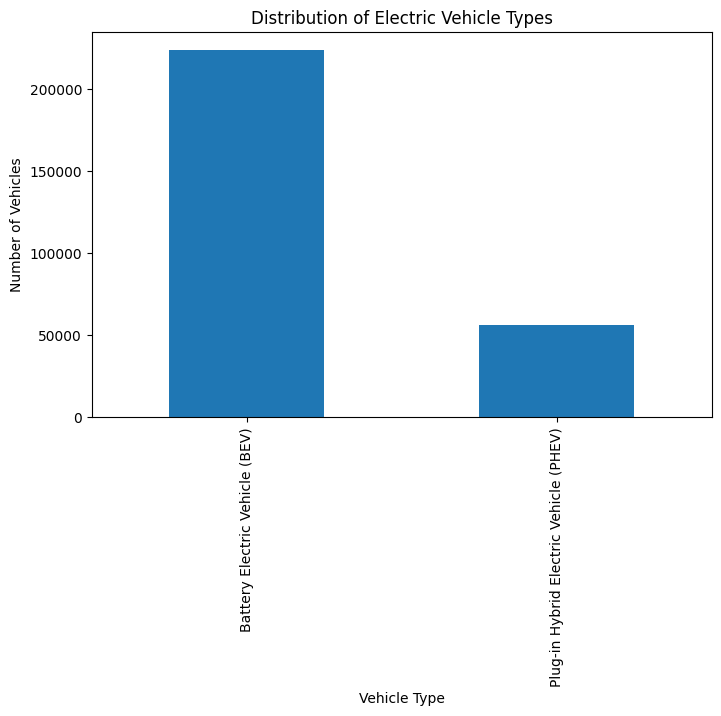

In [20]:
ev_counts = df_clean["Electric Vehicle Type"].value_counts()
plt.figure(figsize=(8,5))
ev_counts.plot(kind="bar")
plt.title("Distribution of Electric Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles")
plt.show()

### Insight

Battery Electric Vehicles (BEVs) account for approximately 80% of all registered electric vehicles, while Plug-in Hybrid Electric Vehicles (PHEVs) make up the remaining share. This indicates a strong consumer preference for fully electric vehicles.

### 2. Top 10 Electric Vehicle Manufacturers

This analysis identifies the most popular electric vehicle manufacturers in the dataset.

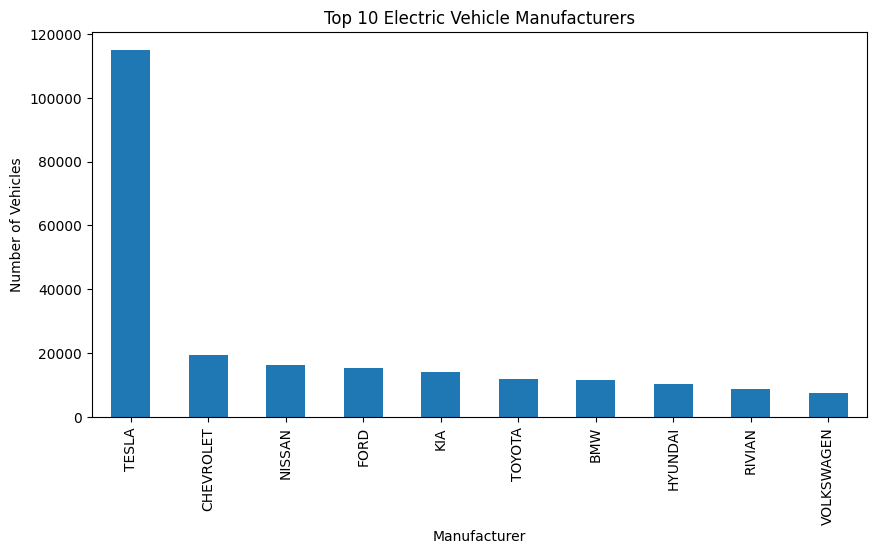

In [21]:
top_makes = df_clean["Make"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_makes.plot(kind="bar")

plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Vehicles")

plt.show()

### Insight

Tesla dominates the EV market with over 100,000 registered vehicles, significantly outperforming all other manufacturers. Chevrolet and Nissan occupy distant second and third positions, highlighting Tesla's strong market leadership.

## 3. Electric Vehicle Adoption Trend by Model Year

This analysis shows how EV registrations have changed over time.

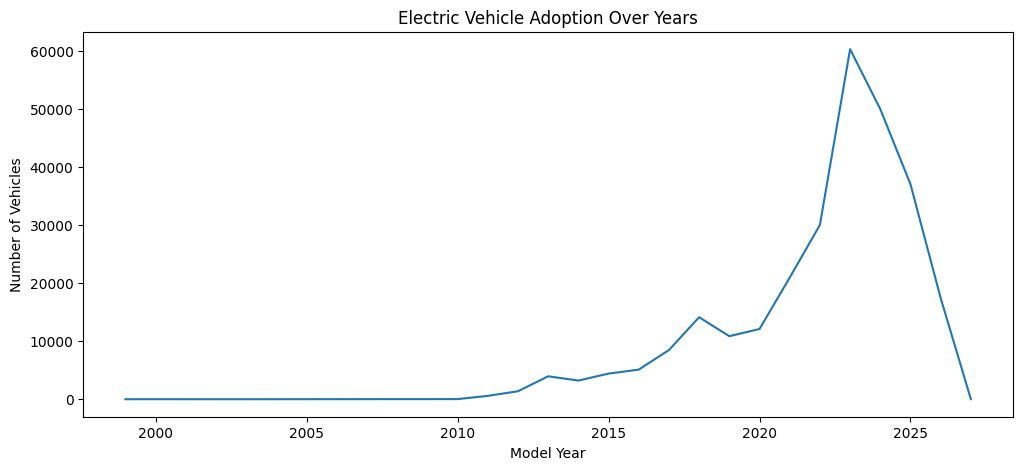

In [22]:
year_counts = df_clean["Model Year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.plot()

plt.title("Electric Vehicle Adoption Over Years")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.show()

### Insight

Electric vehicle adoption remained relatively low until 2015, after which registrations increased rapidly. The strongest growth occurred between 2021 and 2024, reflecting increasing consumer acceptance and improvements in EV technology.

## 4. Geographic Distribution of Electric Vehicles

This analysis identifies counties with the highest concentration of electric vehicles.

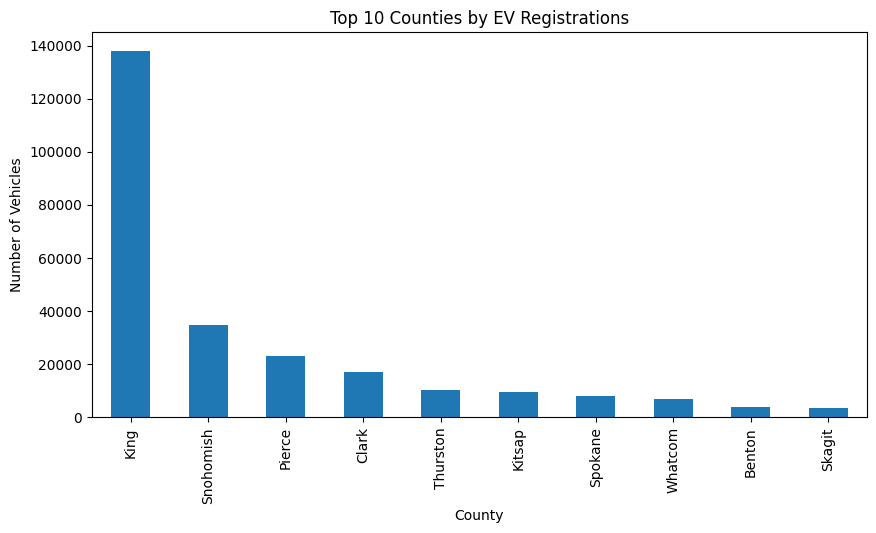

In [23]:
top_counties = df_clean["County"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_counties.plot(kind="bar")

plt.title("Top 10 Counties by EV Registrations")
plt.xlabel("County")
plt.ylabel("Number of Vehicles")

plt.show()

### Insight

King County has the highest concentration of electric vehicles by a large margin. This suggests that urban and economically developed regions are leading the transition toward electric mobility.

## 5. Electric Range Distribution

This analysis examines how electric vehicle ranges are distributed.

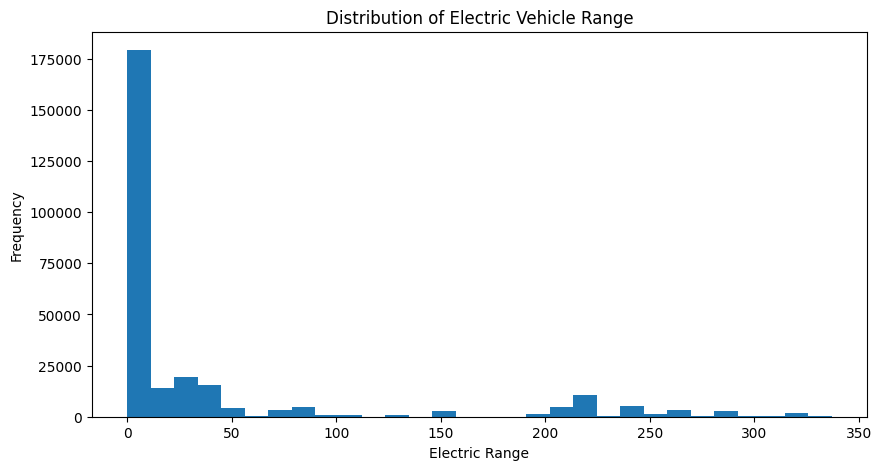

In [24]:
plt.figure(figsize=(10,5))

plt.hist(df_clean["Electric Range"], bins=30)

plt.title("Distribution of Electric Vehicle Range")
plt.xlabel("Electric Range")
plt.ylabel("Frequency")

plt.show()

### Insight

The distribution is highly skewed, with many vehicles having lower electric ranges and a smaller number offering very high ranges. This reflects the coexistence of older EV models and newer long-range vehicles.

## 6. Average Electric Range by Manufacturer

This analysis compares average electric range among manufacturers.

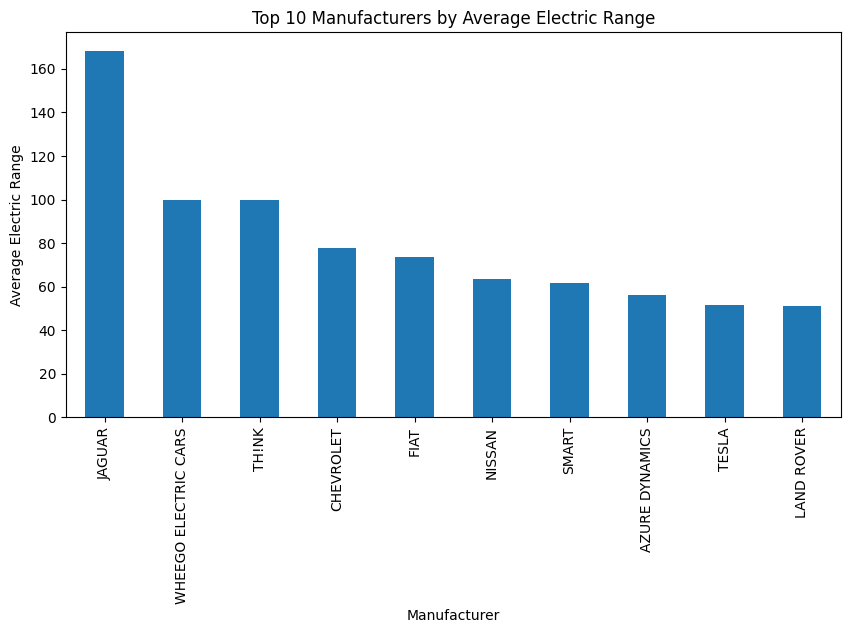

In [25]:
avg_range = (
    df_clean.groupby("Make")["Electric Range"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_range.plot(kind="bar")

plt.title("Top 10 Manufacturers by Average Electric Range")
plt.xlabel("Manufacturer")
plt.ylabel("Average Electric Range")

plt.show()

### Insight

Manufacturers exhibit noticeable differences in average electric range. Jaguar leads the dataset, while Tesla maintains competitive range performance despite its large number of vehicles.

# Task 3 Conclusion

Exploratory Data Analysis revealed several important trends in the electric vehicle market. Battery Electric Vehicles dominate registrations, EV adoption has increased substantially over time, and a small number of manufacturers account for a large share of the market. Geographic analysis also showed that EV adoption varies across counties. These findings provide valuable insights for understanding the growth of electric mobility.

# Task 4: Data Visualization

The objective of this task is to present insights through effective visual representations.

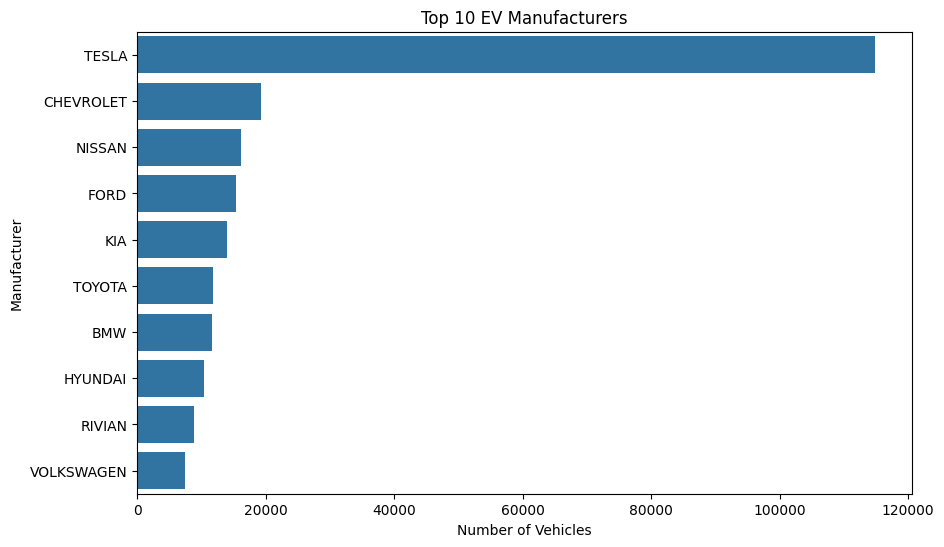

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_makes.values,
    y=top_makes.index
)

plt.title("Top 10 EV Manufacturers")
plt.xlabel("Number of Vehicles")
plt.ylabel("Manufacturer")

plt.show()

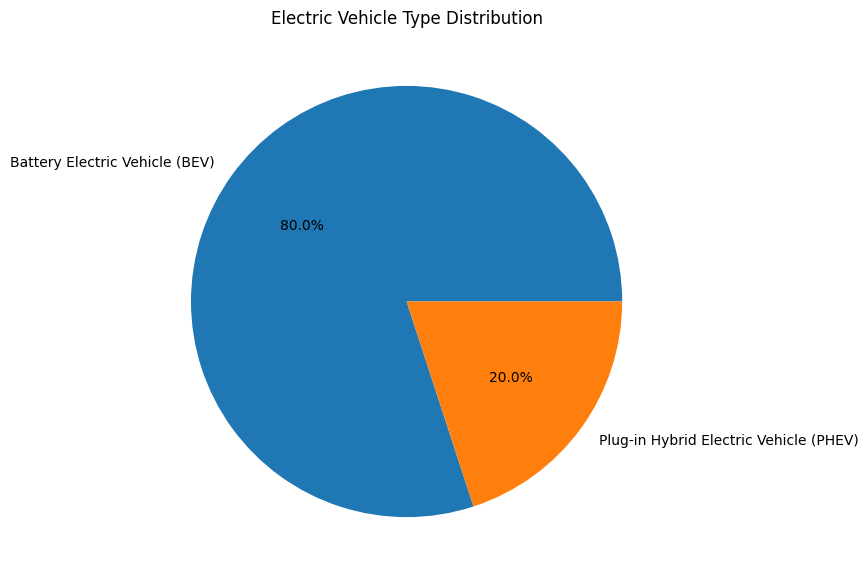

In [27]:
plt.figure(figsize=(7,7))

plt.pie(
    ev_counts,
    labels=ev_counts.index,
    autopct="%1.1f%%"
)

plt.title("Electric Vehicle Type Distribution")

plt.show()

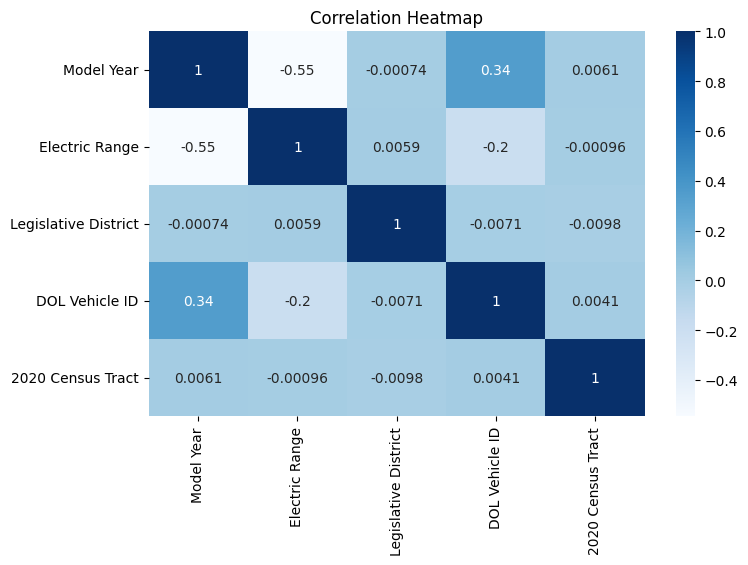

In [28]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df_clean.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

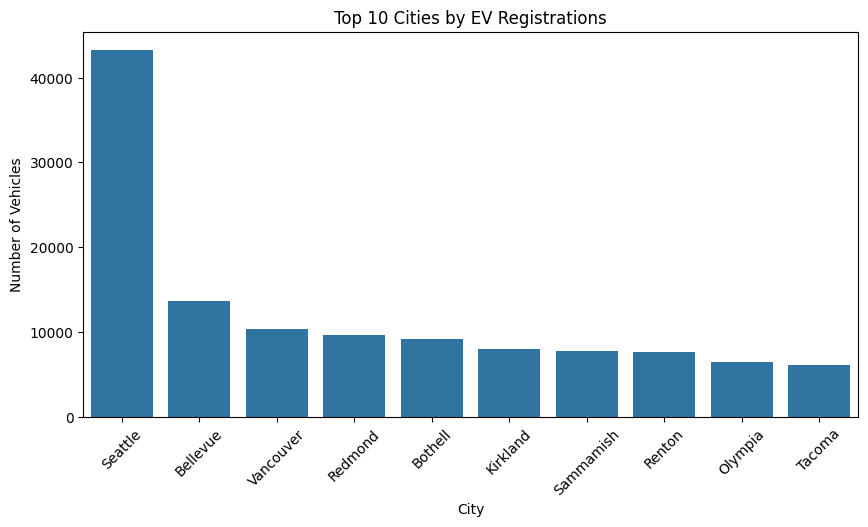

In [29]:
top_cities = df_clean["City"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Cities by EV Registrations")
plt.xlabel("City")
plt.ylabel("Number of Vehicles")

plt.show()

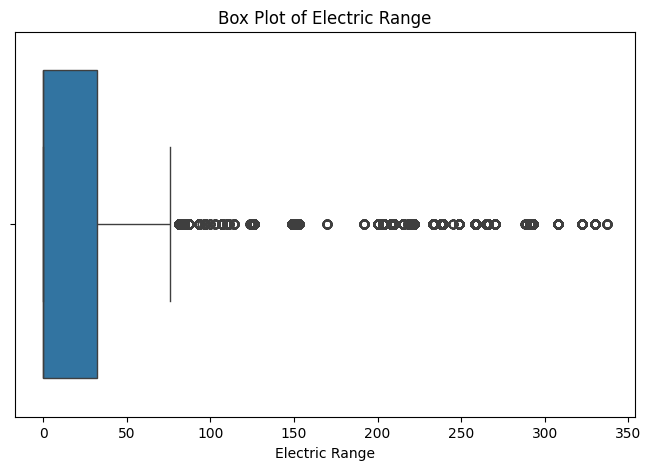

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean["Electric Range"]
)

plt.title("Box Plot of Electric Range")

plt.show()

# Task 4 Conclusion

Data visualization techniques were used to better understand electric vehicle adoption patterns. The visualizations highlighted market dominance by Tesla, increasing EV adoption, regional concentration of registrations, and variations in electric vehicle range. These charts transformed raw data into meaningful insights that support decision-making and trend analysis.

# Task 5: Predictive Modeling

The objective of this task is to build a machine learning model that predicts the electric range of vehicles using selected features from the dataset.

In [31]:
model_df = df_clean[[
    "Model Year",
    "Make",
    "Electric Vehicle Type",
    "Electric Range"
]]

model_df.head()

,Model Year,Make,Electric Vehicle Type,Electric Range
0,2012,NISSAN,Battery Electric Vehicle (BEV),73.0
1,2023,SUBARU,Battery Electric Vehicle (BEV),0.0
2,2018,NISSAN,Battery Electric Vehicle (BEV),151.0
3,2025,BMW,Plug-in Hybrid Electric Vehicle (PHEV),40.0
4,2015,FIAT,Battery Electric Vehicle (BEV),87.0


## Data Preparation

Categorical variables are converted into numerical representations so that machine learning algorithms can process them.

In [32]:
model_df = pd.get_dummies(
    model_df,
    columns=["Make", "Electric Vehicle Type"],
    drop_first=True
)

In [33]:
X = model_df.drop("Electric Range", axis=1)

y = model_df["Electric Range"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
y_pred = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 2.0505594916216268
Root Mean Squared Error: 9.47142168387687
R2 Score: 0.985402472788405


### Model Performance Analysis

The Random Forest Regressor achieved an R² score of 0.9854, indicating excellent predictive accuracy. The model successfully captured the relationship between vehicle characteristics and electric range.

The Mean Absolute Error (2.05) and Root Mean Squared Error (9.47) are relatively low, suggesting that the predicted electric range values are very close to the actual values. Overall, the model demonstrates strong performance and is suitable for predicting electric vehicle range.

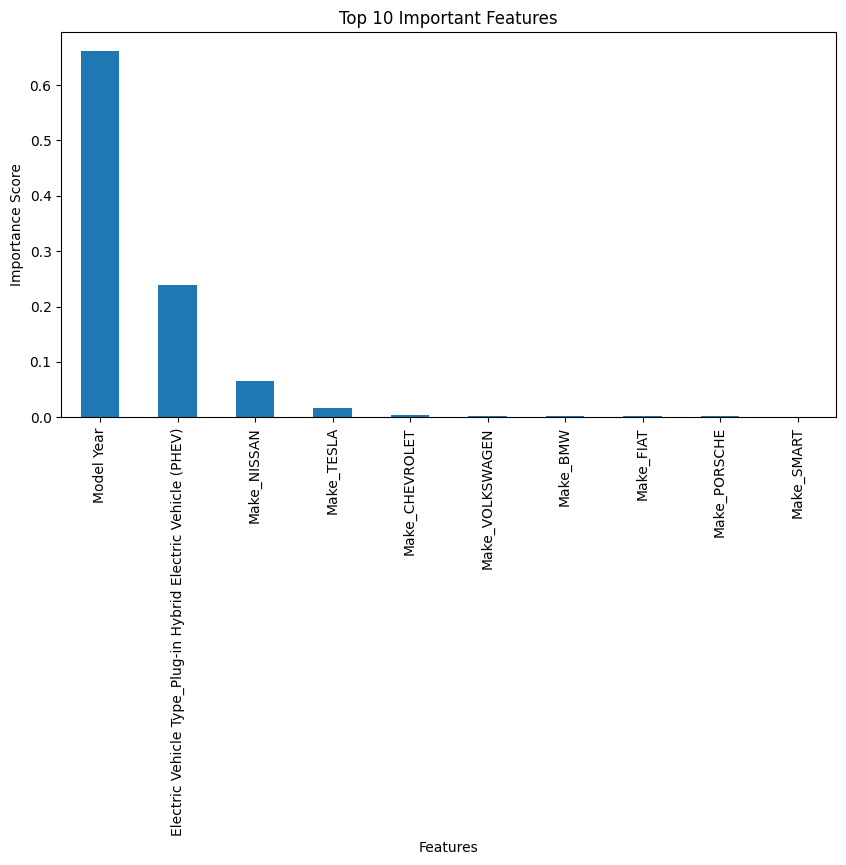

In [38]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)
top_features = feature_importance.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10,5))
top_features.plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

### Insight

Feature importance analysis shows which vehicle characteristics have the greatest influence on electric range prediction. Model Year, Manufacturer, and Vehicle Type contribute significantly to the model's decision-making process.

# Key Findings

1. Battery Electric Vehicles (BEVs) represent the majority of registered electric vehicles.

2. Tesla dominates the EV market, significantly outperforming other manufacturers in total registrations.

3. Electric vehicle adoption has grown rapidly after 2020, indicating increased consumer acceptance.

4. King County has the highest concentration of electric vehicle registrations.

5. Electric vehicle range varies considerably across manufacturers and vehicle models.

6. The Random Forest model achieved an R² score of 98.54%, demonstrating excellent predictive capability.

# Final Conclusion

This project analyzed electric vehicle population data to understand adoption trends, vehicle characteristics, and market patterns.

Key findings include:

- Battery Electric Vehicles dominate the EV market.
- Tesla is the leading manufacturer by vehicle registrations.
- Electric vehicle adoption has increased significantly in recent years.
- EV adoption varies across different geographic regions.
- Vehicle manufacturers differ considerably in average electric range.

A Random Forest machine learning model was developed to predict electric vehicle range using vehicle characteristics. The project demonstrates the practical application of data cleaning, exploratory data analysis, visualization, and machine learning techniques in solving real-world transportation problems.

Overall, the findings highlight the rapid growth of electric mobility and the increasing importance of sustainable transportation technologies.